In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pylake
import os

C:\Users\leroquan\AppData\Local\anaconda3\envs\mitgcm_env\lib\site-packages\pylake\pylake.py:3: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


# Heat fluxes MITgcm

In [2]:
folder_path = r'D:\02-Other lakes calibration\lucerne\crop_results\secchix2-lwdownx0.95'

In [3]:
xr_mitgcm = xr.open_dataset(os.path.join(folder_path,"heatflux.nc"))
#xr_sta = xr_mitgcm.isel(XC=100, YC=100, XG=100, YG=100)

In [4]:
xr_mitgcm['YC'] = np.array(range(len(xr_mitgcm.YC)))*50 + 50
xr_mitgcm['XC'] = np.array(range(len(xr_mitgcm.XC)))*50 + 50

In [5]:
temp_ini = xr_mitgcm.THETA.isel(time=0)
mask_lake = xr.where(abs(temp_ini) > 1e-10, 1, np.nan)

In [6]:
xr_ext_forc = xr.open_dataset(os.path.join(folder_path, "external_forcing.nc"))

#multiplied by -1 to have downward fluxes instead of upward ones
xr_ext_forc['EXFlwnet'] = -1*xr_ext_forc['EXFlwnet']
xr_ext_forc['EXFswnet'] = -1* xr_ext_forc['EXFswnet']
xr_ext_forc['EXFqnet'] = -1* xr_ext_forc['EXFqnet']

#xr_ext_forc_lexplore = xr_ext_forc.sel(XC=49850, YC=18100, XG=49850, YG=18100, method='nearest')

In [7]:
xr_ext_forc['YC'] = xr_mitgcm.YC.values
xr_ext_forc['XC'] = xr_mitgcm.XC.values

In [8]:
xr_ext_forc_masked = xr_ext_forc * mask_lake

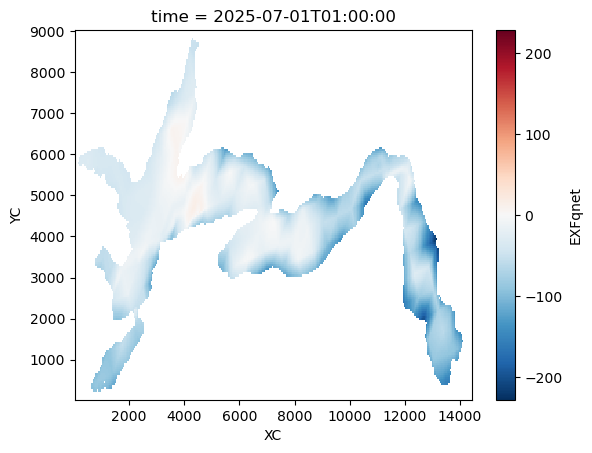

In [9]:
xr_ext_forc_masked.EXFqnet.isel(time=0).plot()

In [10]:
xr_ext_forc_mean = xr_ext_forc_masked.mean(dim=["XC", "YC"], skipna=True)

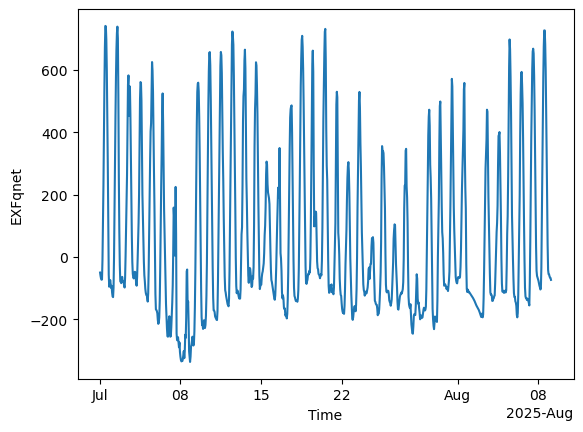

In [11]:
xr_ext_forc_mean.EXFqnet.plot()

In [12]:
# Compute the mean, considering only valid (non-NaN) values
xr_ext_forc_mean = xr_ext_forc_masked.sum(dim=["XC", "YC"]) / mask_lake.sum(dim=["XC", "YC"])

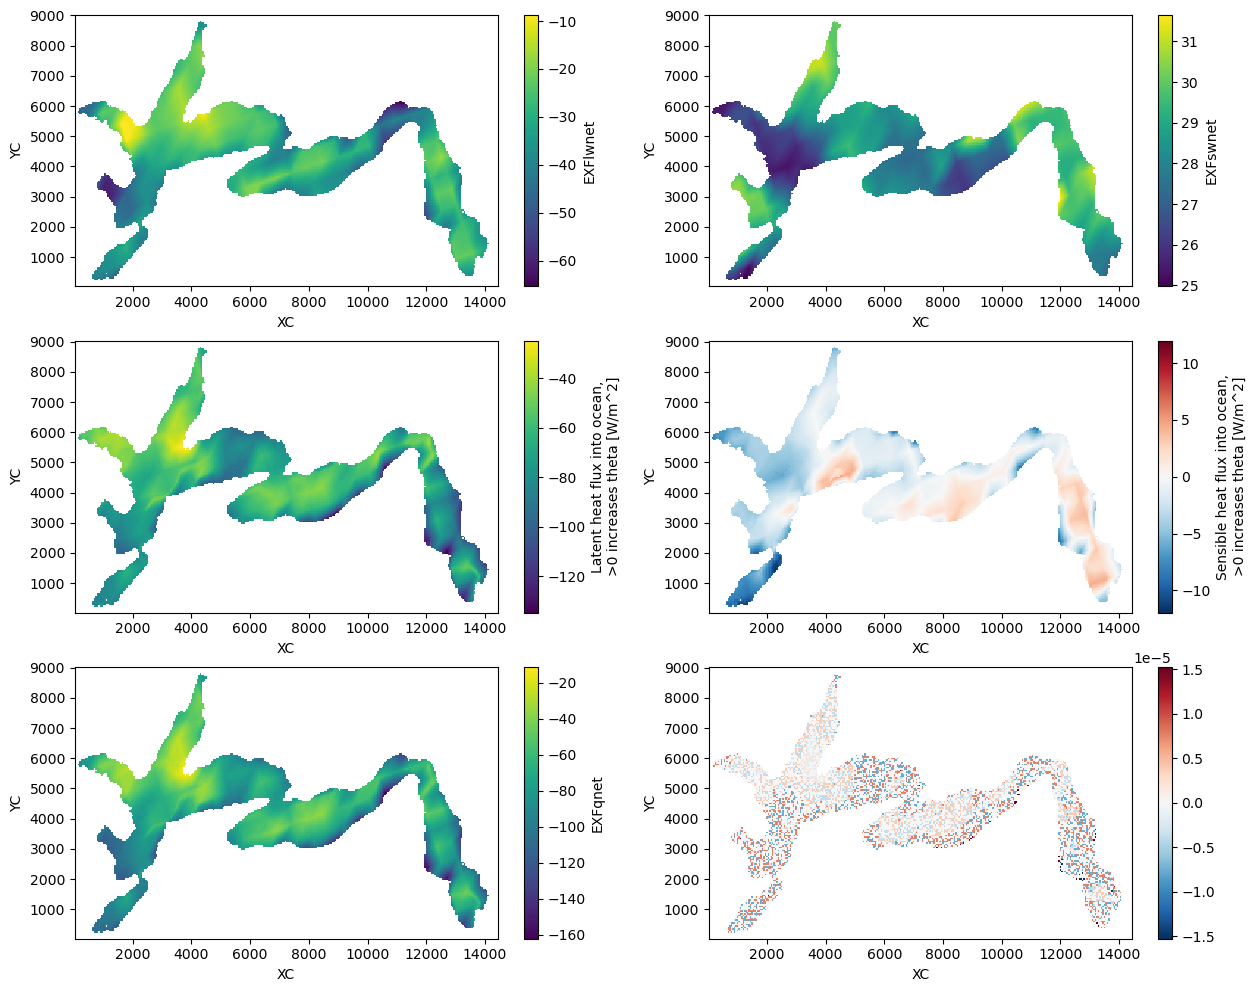

In [13]:
i_time = 4
fig, axs = plt.subplots(3,2,figsize=(15, 12))
xr_ext_forc.EXFlwnet.isel(time=i_time).where(~np.isnan(mask_lake)).plot(ax=axs[0,0])
xr_ext_forc.EXFswnet.isel(time=i_time).where(~np.isnan(mask_lake)).plot(ax=axs[0,1])
xr_ext_forc.EXFhl.isel(time=i_time).where(~np.isnan(mask_lake)).plot(ax=axs[1,0])
xr_ext_forc.EXFhs.isel(time=i_time).where(~np.isnan(mask_lake)).plot(ax=axs[1,1])
xr_ext_forc.EXFqnet.isel(time=i_time).where(~np.isnan(mask_lake)).plot(ax=axs[2,0])

(xr_ext_forc.EXFlwnet.isel(time=i_time)
 + xr_ext_forc.EXFswnet.isel(time=i_time)
 + xr_ext_forc.EXFhl.isel(time=i_time)
 + xr_ext_forc.EXFhs.isel(time=i_time)
 - xr_ext_forc.EXFqnet.isel(time=i_time)).where(~np.isnan(mask_lake)).plot(ax=axs[2,1])

In [14]:
xr_ext_forc_resampled = xr_ext_forc_mean.resample(time='D').mean()

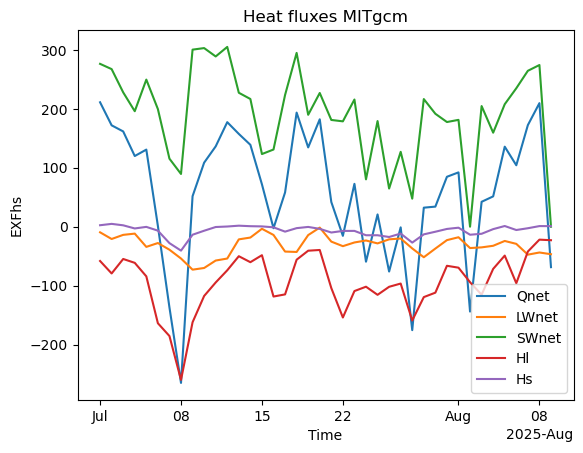

In [15]:
xr_ext_forc_resampled.EXFqnet.plot(label='Qnet')
xr_ext_forc_resampled.EXFlwnet.plot(label='LWnet')
xr_ext_forc_resampled.EXFswnet.plot(label='SWnet')
xr_ext_forc_resampled.EXFhl.plot(label='Hl')
xr_ext_forc_resampled.EXFhs.plot(label='Hs')
plt.title('Heat fluxes MITgcm')
plt.legend()

# Comparison with heat fluxes analysis

Heat fluxes done here: "C:\Users\leroquan\Documents\python\quick_analysis\heat_fluxes\geneva_heat_fluxes.ipynb"
From the simstrat input files
With : "https://renkulab.io/projects/damien.bouffard/2024-limnolab-unil-lake-heat-fluxes\n"

### MITgcm

In [16]:
heat_fluxes = pd.read_csv('heat_fluxes_lucerne_mitgcm_summer2025.csv')

In [17]:
heat_fluxes['time'] = pd.to_datetime(heat_fluxes['time'])
heat_fluxes.index = heat_fluxes['time']

In [18]:
heat_fluxes_resampled = heat_fluxes.resample('D').mean()

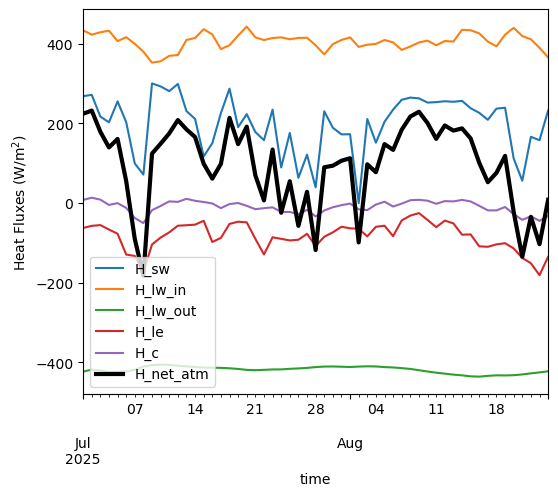

In [19]:
fig, axs = plt.subplots(1, figsize=(6, 5))
heat_fluxes_resampled['H_sw'].plot(ax=axs)
heat_fluxes_resampled['H_lw_in'].plot(ax=axs)
heat_fluxes_resampled['H_lw_out'].plot(ax=axs)
heat_fluxes_resampled['H_le'].plot(ax=axs)
heat_fluxes_resampled['H_c'].plot(ax=axs)
heat_fluxes_resampled['H_net_atm'].plot(ax=axs,lw=3, color ='k')
plt.ylabel('Heat Fluxes (W/m$^2$)')
plt.legend(loc='lower left')

C:\Users\leroquan\AppData\Local\anaconda3\envs\mitgcm_env\lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


Text(0.73, 0.98, '--- Theoritical MITgcm inputs\n── MITgcm inputs')

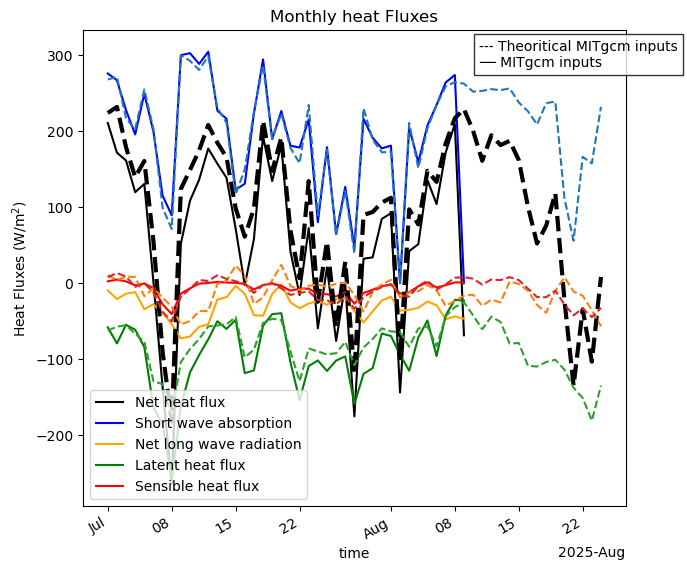

In [21]:
fig, axs = plt.subplots(1, figsize=(7, 7))

xr_ext_forc_resampled.EXFqnet.plot(ax=axs, linestyle='-', color='black', label='Net heat flux')
xr_ext_forc_resampled.EXFswnet.plot(ax=axs, linestyle='-', color = 'blue', label='Short wave absorption')
xr_ext_forc_resampled.EXFlwnet.plot(ax=axs, linestyle='-', color='orange', label='Net long wave radiation')
xr_ext_forc_resampled.EXFhl.plot(ax=axs, linestyle='-', color ='green', label='Latent heat flux')
xr_ext_forc_resampled.EXFhs.plot(ax=axs, linestyle='-', color='red', label='Sensible heat flux')

plt.plot(heat_fluxes_resampled.index, heat_fluxes_resampled['H_net_atm'], label='',lw=3, color ='k', linestyle='--')
heat_fluxes_resampled['H_sw'].plot(ax=axs, label='', linestyle='--')
(heat_fluxes_resampled['H_lw_in'] + heat_fluxes_resampled['H_lw_out']).plot(ax=axs, label='', linestyle='--')
heat_fluxes_resampled['H_le'].plot(ax=axs, label='', linestyle='--') # Latent heat flux
heat_fluxes_resampled['H_c'].plot(ax=axs, label='', linestyle='--') # Sensible heat flux

#plt.xlim(left=xr_ext_forc_resampled.time.isel(time=0).values, right=xr_ext_forc_resampled.time.isel(time=-1).values)

plt.ylabel('Heat Fluxes (W/m$^2$)')
plt.legend(loc='lower left')
plt.title('Monthly heat Fluxes')

# Add legend-style text in the upper right
plt.text(0.73, 0.98,
         "--- Theoritical MITgcm inputs\n"
         "── MITgcm inputs",
         transform=axs.transAxes,
         fontsize=10,
         verticalalignment='top',
         horizontalalignment='left',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

### Simstrat

In [22]:
heat_fluxes_simstrat = pd.read_csv('heat_fluxes_lucerne_simstrat_summer2025.csv')

In [23]:
heat_fluxes_simstrat['time'] = pd.to_datetime(heat_fluxes_simstrat['time'])
heat_fluxes_simstrat.index = heat_fluxes_simstrat['time']

In [24]:
heat_fluxes_simstrat_resampled = heat_fluxes_simstrat.resample('D').mean()

In [25]:
xr_ext_forc_resampled.time.isel(time=-1).values

np.datetime64('2025-08-09T00:00:00.000000000')

C:\Users\leroquan\AppData\Local\anaconda3\envs\mitgcm_env\lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


Text(0.73, 0.98, '--- Simstrat inputs\n── MITgcm inputs')

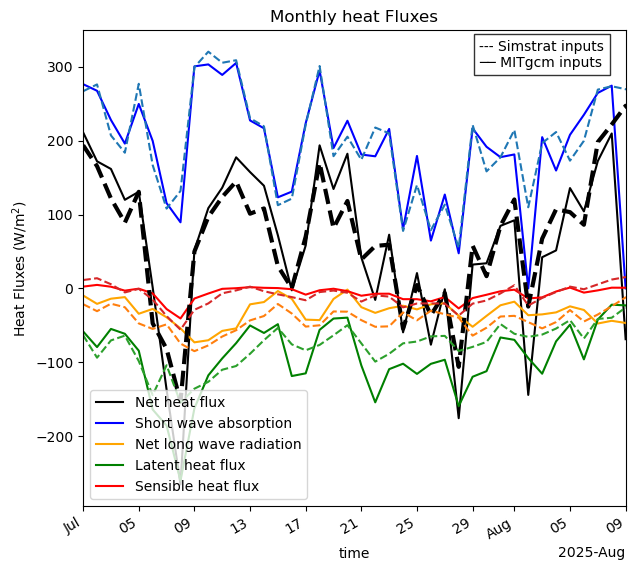

In [26]:
fig, axs = plt.subplots(1, figsize=(7, 7))

xr_ext_forc_resampled.EXFqnet.plot(ax=axs, linestyle='-', color='black', label='Net heat flux')
xr_ext_forc_resampled.EXFswnet.plot(ax=axs, linestyle='-', color = 'blue', label='Short wave absorption')
xr_ext_forc_resampled.EXFlwnet.plot(ax=axs, linestyle='-', color='orange', label='Net long wave radiation')
xr_ext_forc_resampled.EXFhl.plot(ax=axs, linestyle='-', color ='green', label='Latent heat flux')
xr_ext_forc_resampled.EXFhs.plot(ax=axs, linestyle='-', color='red', label='Sensible heat flux')

plt.plot(heat_fluxes_simstrat_resampled.index, heat_fluxes_simstrat_resampled['H_net_atm'], label='',lw=3, color ='k', linestyle='--')
heat_fluxes_simstrat_resampled['H_sw'].plot(ax=axs, label='', linestyle='--')
(heat_fluxes_simstrat_resampled['H_lw_in'] + heat_fluxes_simstrat_resampled['H_lw_out']).plot(ax=axs, label='', linestyle='--')
heat_fluxes_simstrat_resampled['H_le'].plot(ax=axs, label='', linestyle='--') # Latent heat flux
heat_fluxes_simstrat_resampled['H_c'].plot(ax=axs, label='', linestyle='--') # Sensible heat flux

plt.xlim(left=xr_ext_forc_resampled.time.isel(time=0).values, right=xr_ext_forc_resampled.time.isel(time=-1).values)

plt.ylabel('Heat Fluxes (W/m$^2$)')
plt.legend(loc='lower left')
plt.title('Monthly heat Fluxes')

# Add legend-style text in the upper right
plt.text(0.73, 0.98, 
         "--- Simstrat inputs\n"
         "── MITgcm inputs", 
         transform=axs.transAxes, 
         fontsize=10, 
         verticalalignment='top', 
         horizontalalignment='left', 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

# Net heat fluxes from measurements

In [ ]:
xr_measure = xr.open_dataset(f'../../data/datalakes/geneva_idronaut/2024.nc')

In [ ]:
def interpolate_to_axis(xr_ds, axis, axis_name, max_gap=None):
    interp_ds = xr_ds.interp({axis_name: axis})

    if max_gap is not None:
        nearest_values = xr_ds[axis_name].sel({axis_name: axis}, method="nearest")
        diff = abs(nearest_values - axis)
        invalid_axis = axis[np.array(diff <= max_gap)]
        mask = interp_ds[axis_name].isin(invalid_axis)
        interp_ds = interp_ds.where(mask, np.nan)
    
    return interp_ds

In [ ]:
common_time_axis = pd.date_range(
    start=pd.Timestamp('2024-02-01'), 
    end=pd.Timestamp('2024-12-01'), 
    freq='3h'
)
common_depth_axis = np.arange(0, -61, -1)

meas_selected = xr_measure['temp']
meas_interp_time = interpolate_to_axis(meas_selected, common_time_axis, 'time', np.timedelta64(15, 'D') )
meas_interp = interpolate_to_axis(meas_interp_time, common_depth_axis, 'depth')

In [ ]:
temp_meas = meas_interp.values
depth = meas_interp.depth.values
bthA = np.ones(61)
bthD = depth

In [ ]:
heat_content_meas = pylake.heat_content(temp_meas, bthA=bthA, bthD=bthD, depth=depth, s=0.2)

In [ ]:
heat_content_meas = heat_content_meas.assign_coords(time=meas_interp['time'])

In [ ]:
heat_fluxes_meas = (heat_content_meas.diff(dim='time')/3600)

In [ ]:
heat_fluxes_meas.plot()

# Heat fluxes from MITgcm temperature

In [ ]:
xr_mitgcm_year = xr.open_dataset(r"D:\new_geneva_200m\cropped_results_nc\lexplore_temp_depth_time.nc")

In [ ]:
crop_mitgcm = xr_mitgcm_year.isel(Z=range(0,51))
temp_mitgcm = crop_mitgcm['THETA'].values
depth_mitgcm = crop_mitgcm.Z.values
bthA_mitgcm = np.ones(len(depth_mitgcm))
bthD_mitgcm = depth_mitgcm

In [ ]:
heat_content_mitgcm = pylake.heat_content(temp_mitgcm, bthA=bthA_mitgcm, bthD=bthD_mitgcm, depth=depth_mitgcm, s=0.2)

In [ ]:
heat_content_mitgcm = heat_content_mitgcm.assign_coords(time=crop_mitgcm['time'])

In [ ]:
heat_fluxes_mitgcm = (heat_content_mitgcm.diff(dim='time')/3600)